<a href="https://colab.research.google.com/github/coolsengar/Data-Analysis-Project/blob/main/World_Population_Analysis_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### World population Analysis Using the dataset from 1970-2022

In [106]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from plotly.subplots import make_subplots
import plotly.express as px
import plotly.offline as py
!pip install pycountry
import pycountry

import warnings
warnings.filterwarnings('ignore')

In [107]:
# import dataset
data = pd.read_csv('/content/world_population.csv')
data.head()

,Rank,CCA3,Country/Territory,Capital,Continent,2022 Population,2020 Population,2015 Population,2010 Population,2000 Population,1990 Population,1980 Population,1970 Population,Area (km²),Density (per km²),Growth Rate,World Population Percentage
0,36,AFG,Afghanistan,Kabul,Asia,41128771,38972230,33753499,28189672,19542982,10694796,12486631,10752971,652230,63.0587,1.0257,0.52
1,138,ALB,Albania,Tirana,Europe,2842321,2866849,2882481,2913399,3182021,3295066,2941651,2324731,28748,98.8702,0.9957,0.04
2,34,DZA,Algeria,Algiers,Africa,44903225,43451666,39543154,35856344,30774621,25518074,18739378,13795915,2381741,18.8531,1.0164,0.56
3,213,ASM,American Samoa,Pago Pago,Oceania,44273,46189,51368,54849,58230,47818,32886,27075,199,222.4774,0.9831,0.00
4,203,AND,Andorra,Andorra la Vella,Europe,79824,77700,71746,71519,66097,53569,35611,19860,468,170.5641,1.0100,0.00


In [108]:
data.shape

(234, 17)

In [109]:
# more infor
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 234 entries, 0 to 233
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Rank                         234 non-null    int64  
 1   CCA3                         234 non-null    object 
 2   Country/Territory            234 non-null    object 
 3   Capital                      234 non-null    object 
 4   Continent                    234 non-null    object 
 5   2022 Population              234 non-null    int64  
 6   2020 Population              234 non-null    int64  
 7   2015 Population              234 non-null    int64  
 8   2010 Population              234 non-null    int64  
 9   2000 Population              234 non-null    int64  
 10  1990 Population              234 non-null    int64  
 11  1980 Population              234 non-null    int64  
 12  1970 Population              234 non-null    int64  
 13  Area (km²)          

In [110]:
# mathematical analysis
data.describe()

,Rank,2022 Population,2020 Population,2015 Population,2010 Population,2000 Population,1990 Population,1980 Population,1970 Population,Area (km²),Density (per km²),Growth Rate,World Population Percentage
count,234.000000,2.340000e+02,2.340000e+02,2.340000e+02,2.340000e+02,2.340000e+02,2.340000e+02,2.340000e+02,2.340000e+02,2.340000e+02,234.000000,234.000000,234.000000
mean,117.500000,3.407441e+07,3.350107e+07,3.172996e+07,2.984524e+07,2.626947e+07,2.271022e+07,1.898462e+07,1.578691e+07,5.814494e+05,452.127044,1.009577,0.427051
std,67.694165,1.367664e+08,1.355899e+08,1.304050e+08,1.242185e+08,1.116982e+08,9.783217e+07,8.178519e+07,6.779509e+07,1.761841e+06,2066.121904,0.013385,1.714977
min,1.000000,5.100000e+02,5.200000e+02,5.640000e+02,5.960000e+02,6.510000e+02,7.000000e+02,7.330000e+02,7.520000e+02,1.000000e+00,0.026100,0.912000,0.000000
25%,59.250000,4.197385e+05,4.152845e+05,4.046760e+05,3.931490e+05,3.272420e+05,2.641158e+05,2.296142e+05,1.559970e+05,2.650000e+03,38.417875,1.001775,0.010000
50%,117.500000,5.559944e+06,5.493074e+06,5.307400e+06,4.942770e+06,4.292907e+06,3.825410e+06,3.141146e+06,2.604830e+06,8.119950e+04,95.346750,1.007900,0.070000
75%,175.750000,2.247650e+07,2.144798e+07,1.973085e+07,1.915957e+07,1.576230e+07,1.186923e+07,9.826054e+06,8.817329e+06,4.304258e+05,238.933250,1.016950,0.280000
max,234.000000,1.425887e+09,1.424930e+09,1.393715e+09,1.348191e+09,1.264099e+09,1.153704e+09,9.823725e+08,8.225344e+08,1.709824e+07,23172.266700,1.069100,17.880000


In [111]:
# correlation
# correlation of numerical features
numerical_data = data.select_dtypes(include=np.number)
correlation_matrix = numerical_data.corr()
correlation_matrix

,Rank,2022 Population,2020 Population,2015 Population,2010 Population,2000 Population,1990 Population,1980 Population,1970 Population,Area (km²),Density (per km²),Growth Rate,World Population Percentage
Rank,1.000000,-0.358361,-0.355854,-0.351222,-0.347461,-0.341057,-0.336152,-0.335246,-0.335379,-0.383774,0.129436,-0.224561,-0.358464
2022 Population,-0.358361,1.000000,0.999946,0.999490,0.998629,0.994605,0.987228,0.980285,0.973162,0.453411,-0.027618,-0.020863,0.999999
2020 Population,-0.355854,0.999946,1.000000,0.999763,0.999105,0.995583,0.988724,0.982121,0.975254,0.454993,-0.027358,-0.025116,0.999944
2015 Population,-0.351222,0.999490,0.999763,1.000000,0.999783,0.997340,0.991594,0.985724,0.979414,0.458240,-0.026857,-0.032154,0.999487
2010 Population,-0.347461,0.998629,0.999105,0.999783,1.000000,0.998593,0.993929,0.988786,0.983042,0.461936,-0.026505,-0.037983,0.998626
2000 Population,-0.341057,0.994605,0.995583,0.997340,0.998593,1.000000,0.998336,0.995160,0.990956,0.473933,-0.026139,-0.050515,0.994598
1990 Population,-0.336152,0.987228,0.988724,0.991594,0.993929,0.998336,1.000000,0.999042,0.996602,0.486764,-0.026224,-0.062397,0.987218
1980 Population,-0.335246,0.980285,0.982121,0.985724,0.988786,0.995160,0.999042,1.000000,0.999194,0.498166,-0.026587,-0.072349,0.980273
1970 Population,-0.335379,0.973162,0.975254,0.979414,0.983042,0.990956,0.996602,0.999194,1.000000,0.509940,-0.026881,-0.081313,0.973150
Area (km²),-0.383774,0.453411,0.454993,0.458240,0.461936,0.473933,0.486764,0.498166,0.509940,1.000000,-0.063128,-0.013970,0.453284


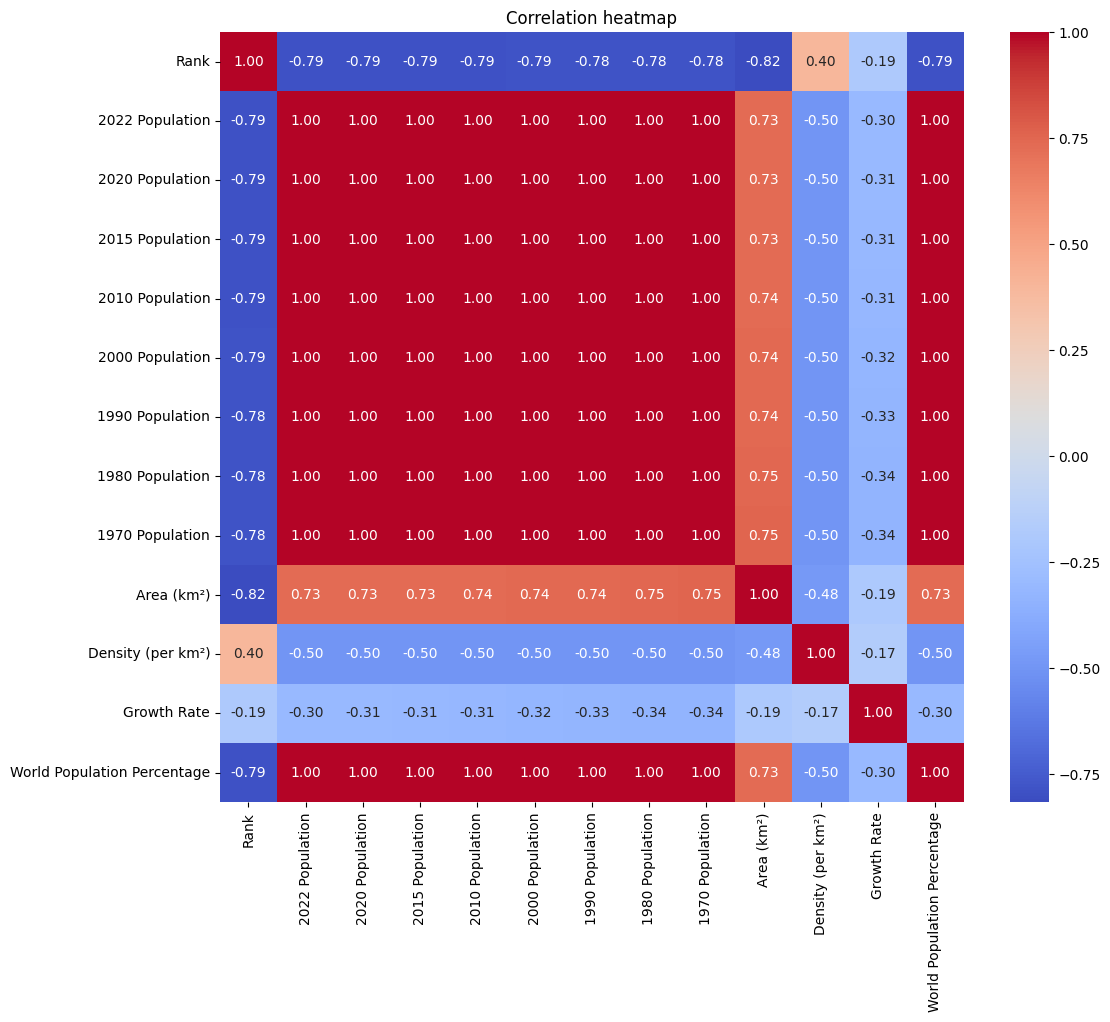

In [112]:
# create heatmap

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation heatmap')
plt.show()


In [113]:
# check missing values
data.isnull().sum()

,0
Rank,0
CCA3,0
Country/Territory,0
Capital,0
Continent,0
2022 Population,0
2020 Population,0
2015 Population,0
2010 Population,0
2000 Population,0


## Data Preprocessing

In [114]:
data.columns

Index(['Rank', 'CCA3', 'Country/Territory', 'Capital', 'Continent',
       '2022 Population', '2020 Population', '2015 Population',
       '2010 Population', '2000 Population', '1990 Population',
       '1980 Population', '1970 Population', 'Area (km²)', 'Density (per km²)',
       'Growth Rate', 'World Population Percentage'],
      dtype='object')

In [115]:
df = data # copying the data

In [116]:
df.head()

,Rank,CCA3,Country/Territory,Capital,Continent,2022 Population,2020 Population,2015 Population,2010 Population,2000 Population,1990 Population,1980 Population,1970 Population,Area (km²),Density (per km²),Growth Rate,World Population Percentage
0,36,AFG,Afghanistan,Kabul,Asia,41128771,38972230,33753499,28189672,19542982,10694796,12486631,10752971,652230,63.0587,1.0257,0.52
1,138,ALB,Albania,Tirana,Europe,2842321,2866849,2882481,2913399,3182021,3295066,2941651,2324731,28748,98.8702,0.9957,0.04
2,34,DZA,Algeria,Algiers,Africa,44903225,43451666,39543154,35856344,30774621,25518074,18739378,13795915,2381741,18.8531,1.0164,0.56
3,213,ASM,American Samoa,Pago Pago,Oceania,44273,46189,51368,54849,58230,47818,32886,27075,199,222.4774,0.9831,0.00
4,203,AND,Andorra,Andorra la Vella,Europe,79824,77700,71746,71519,66097,53569,35611,19860,468,170.5641,1.0100,0.00


In [117]:
df.rename(columns={'Country/Territory': 'Country'}, inplace=True)

In [118]:
df.head(0)

,Rank,CCA3,Country,Capital,Continent,2022 Population,2020 Population,2015 Population,2010 Population,2000 Population,1990 Population,1980 Population,1970 Population,Area (km²),Density (per km²),Growth Rate,World Population Percentage


In [119]:
'2022 Population'.split(' ')[0]

'2022'

In [120]:
# change year_population to year
for col in df.columns:
  if 'Population' and '0' in col:
   df = df.rename(columns={col: col.split(' ')[0]})

df.head(5)

,Rank,CCA3,Country,Capital,Continent,2022,2020,2015,2010,2000,1990,1980,1970,Area (km²),Density (per km²),Growth Rate,World Population Percentage
0,36,AFG,Afghanistan,Kabul,Asia,41128771,38972230,33753499,28189672,19542982,10694796,12486631,10752971,652230,63.0587,1.0257,0.52
1,138,ALB,Albania,Tirana,Europe,2842321,2866849,2882481,2913399,3182021,3295066,2941651,2324731,28748,98.8702,0.9957,0.04
2,34,DZA,Algeria,Algiers,Africa,44903225,43451666,39543154,35856344,30774621,25518074,18739378,13795915,2381741,18.8531,1.0164,0.56
3,213,ASM,American Samoa,Pago Pago,Oceania,44273,46189,51368,54849,58230,47818,32886,27075,199,222.4774,0.9831,0.00
4,203,AND,Andorra,Andorra la Vella,Europe,79824,77700,71746,71519,66097,53569,35611,19860,468,170.5641,1.0100,0.00


In [121]:
# check for null objects
df.isnull().sum()

,0
Rank,0
CCA3,0
Country,0
Capital,0
Continent,0
2022,0
2020,0
2015,0
2010,0
2000,0


In [122]:
df.duplicated().sum()

np.int64(0)

In [123]:
df.nunique()

,0
Rank,234
CCA3,234
Country,234
Capital,234
Continent,6
2022,234
2020,234
2015,234
2010,234
2000,234


### observation
1. No null values (data is cleaned)
2. No Duplicate values.
3.234 unique contries

In [124]:
df.columns

Index(['Rank', 'CCA3', 'Country', 'Capital', 'Continent', '2022', '2020',
       '2015', '2010', '2000', '1990', '1980', '1970', 'Area (km²)',
       'Density (per km²)', 'Growth Rate', 'World Population Percentage'],
      dtype='object')

In [125]:
df.describe().T.sort_values(ascending=0, by='mean')

,count,mean,std,min,25%,50%,75%,max
2022,234.0,3.407441e+07,1.367664e+08,510.0000,419738.500000,5.559944e+06,2.247650e+07,1.425887e+09
2020,234.0,3.350107e+07,1.355899e+08,520.0000,415284.500000,5.493074e+06,2.144798e+07,1.424930e+09
2015,234.0,3.172996e+07,1.304050e+08,564.0000,404676.000000,5.307400e+06,1.973085e+07,1.393715e+09
2010,234.0,2.984524e+07,1.242185e+08,596.0000,393149.000000,4.942770e+06,1.915957e+07,1.348191e+09
2000,234.0,2.626947e+07,1.116982e+08,651.0000,327242.000000,4.292907e+06,1.576230e+07,1.264099e+09
1990,234.0,2.271022e+07,9.783217e+07,700.0000,264115.750000,3.825410e+06,1.186923e+07,1.153704e+09
1980,234.0,1.898462e+07,8.178519e+07,733.0000,229614.250000,3.141146e+06,9.826054e+06,9.823725e+08
1970,234.0,1.578691e+07,6.779509e+07,752.0000,155997.000000,2.604830e+06,8.817329e+06,8.225344e+08
Area (km²),234.0,5.814494e+05,1.761841e+06,1.0000,2650.000000,8.119950e+04,4.304258e+05,1.709824e+07
Density (per km²),234.0,4.521270e+02,2.066122e+03,0.0261,38.417875,9.534675e+01,2.389332e+02,2.317227e+04


In [126]:
continent_df = df.groupby(by='Continent').sum()
continent_df

,Rank,CCA3,Country,Capital,2022,2020,2015,2010,2000,1990,1980,1970,Area (km²),Density (per km²),Growth Rate,World Population Percentage
Continent,,,,,,,,,,,,,,,,
Africa,5253,DZAAGOBENBWABFABDICMRCPVCAFTCDCOMDJICODEGYGNQE...,AlgeriaAngolaBeninBotswanaBurkina FasoBurundiC...,AlgiersLuandaPorto-NovoGaboroneOuagadougouBuju...,1426730932,1360671810,1201102442,1055228072,818946032,638150629,481536377,365444348,30317963,7127.7158,58.2109,17.87
Asia,3878,AFGARMAZEBHRBGDBTNBRNKHMCHNGEOHKGINDIDNIRNIRQI...,AfghanistanArmeniaAzerbaijanBahrainBangladeshB...,KabulYerevanBakuManamaDhakaThimphuBandar Seri ...,4721383274,4663086535,4458250182,4220041327,3735089604,3210563577,2635334228,2144906290,32138141,51251.2068,50.4692,59.19
Europe,6225,ALBANDAUTBLRBELBIHBGRHRVCYPCZEDNKESTFROFINFRAD...,AlbaniaAndorraAustriaBelarusBelgiumBosnia and ...,TiranaAndorra la VellaViennaMinskBrusselsSaraj...,743147538,745792196,741535608,735613934,726093423,720320797,692527159,655923991,23010411,33166.2371,50.1128,9.33
North America,6437,AIAATGABWBHSBRBBLZBMUVGBCANCYMCRICUBCUWDMADOMS...,AnguillaAntigua and BarbudaArubaBahamasBarbado...,The ValleySaint John’sOranjestadNassauBridgeto...,600296136,594236593,570383850,542720651,486069584,421266425,368293361,315434606,24244178,10910.4703,40.1670,7.51
Oceania,4336,ASMAUSCOKFJIPYFGUMKIRMHLFSMNRUNCLNZLNIUNFKPLWP...,American SamoaAustraliaCook IslandsFijiFrench ...,Pago PagoCanberraAvaruaSuvaPapeeteHagåtñaTaraw...,45038554,43933426,40403283,37102764,31222778,26743822,22920240,19480270,8515081,3048.4905,23.1698,0.55
South America,1366,ARGBOLBRACHLCOLECUFLKGUFGUYPRYPERSURURYVEN,ArgentinaBoliviaBrazilChileColombiaEcuadorFalk...,Buenos AiresSucreBrasiliaSantiagoBogotaQuitoSt...,436816608,431530043,413134396,393078250,349634282,297146415,241789006,192947156,17833382,293.6077,14.1114,5.48


#Exploratory Data Analysis

#### for latest population year 2022

In [127]:
print("Population in 2022 :", df['2022'].sum())

Population in 2022 : 7973413042


In [128]:
population_by_year = df.iloc[:,5:13].sum()[::-1]
population_by_year

,0
1970,3694136661
1980,4442400371
1990,5314191665
2000,6147055703
2010,6983784998
2015,7424809761
2020,7839250603
2022,7973413042


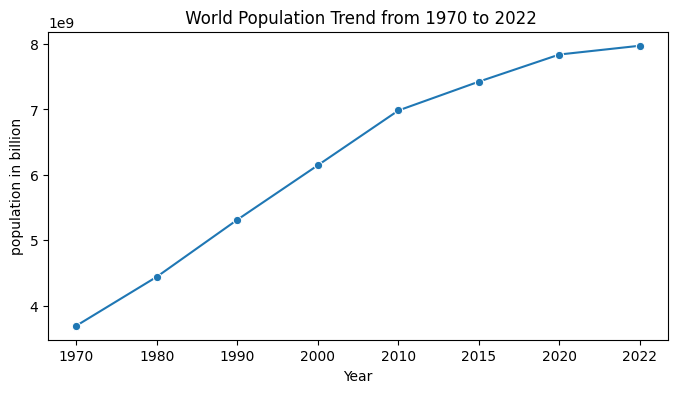

In [129]:
# trend for population since 1970
plt.figure(figsize=(8, 4))
sns.lineplot(x=population_by_year.index, y=population_by_year.values, marker='o')
plt.ylabel("population in billion")
plt.xlabel("Year")
plt.title(" World Population Trend from 1970 to 2022")
plt.show()

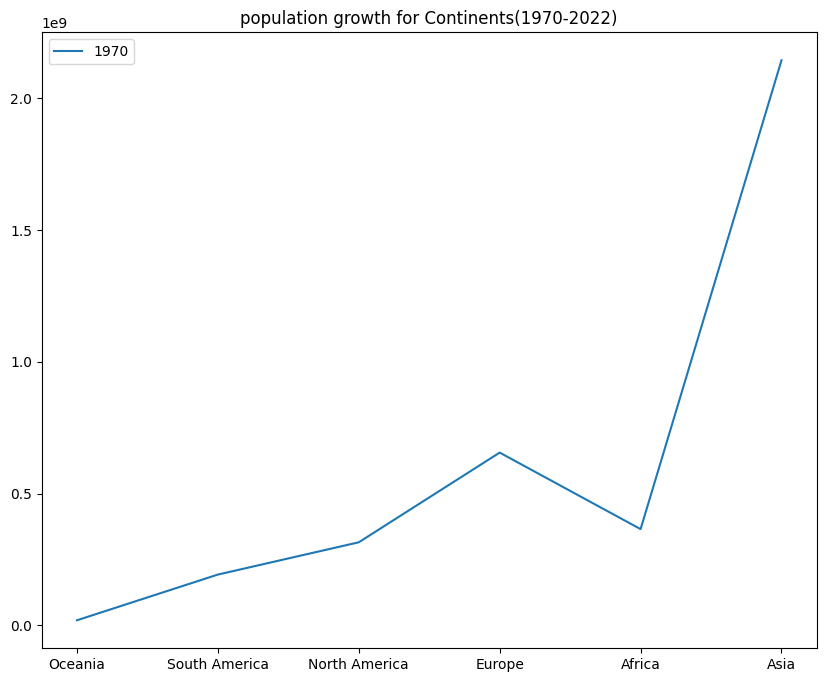

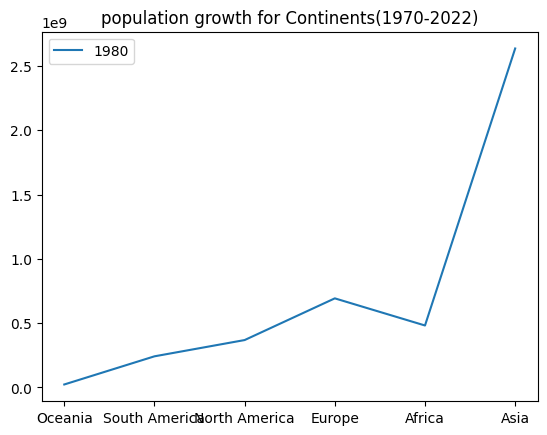

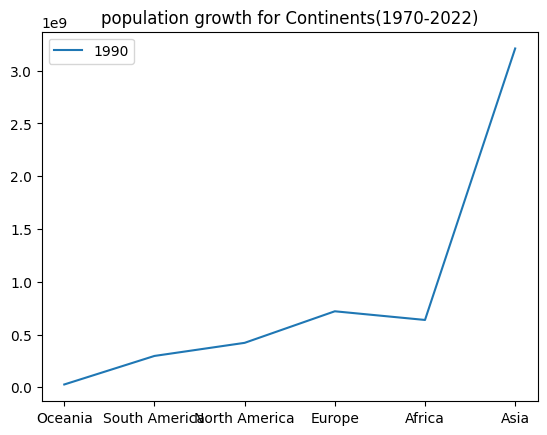

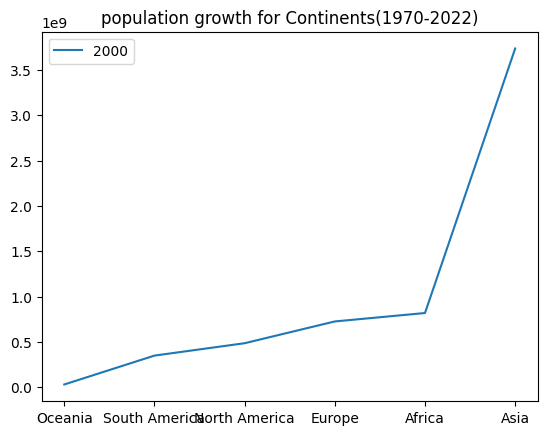

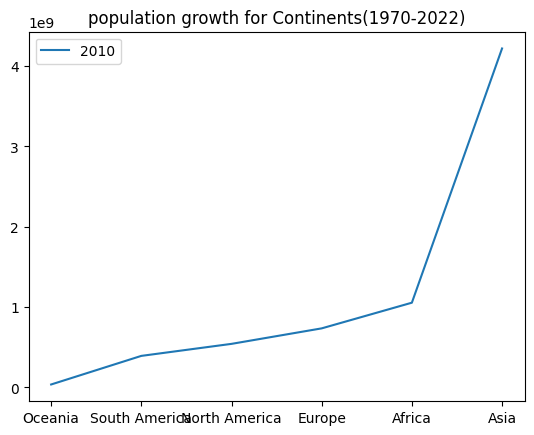

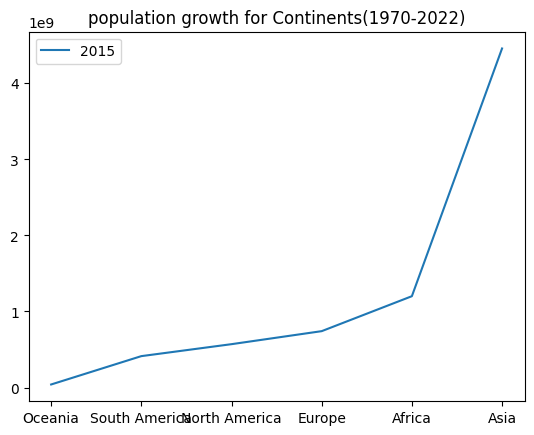

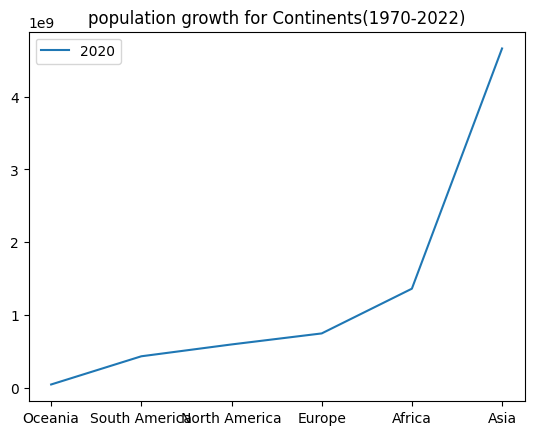

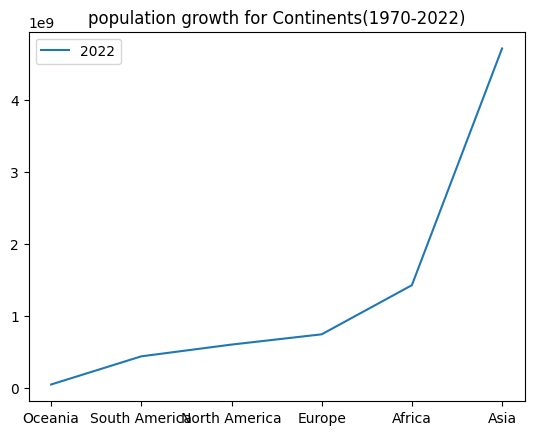

In [130]:
continent_df.sort_values(by='2022', inplace=True)
plt.figure(figsize=(10,8))
population_features = ['2022', '2020' , '2015' , '2010' , '2000' , '1990' , '1980' , '1970']
population_features.reverse()
for feature in population_features:
  plt.plot(continent_df[feature],label=feature)
  plt.title('population growth for Continents(1970-2022)')
  plt.legend()
  plt.show()

Visualize on Map

In [131]:
#!pip install pycountry
import pycountry
countries = {}
for country in pycountry.countries:
  countries[country.name] = country.alpha_3

In [132]:
# countries
import plotly.express as px

# Assuming 'df' contains the population data
df_2022 = df[['Country', '2022']].copy()  # Create a DataFrame with 'Country' and '2022' columns
df_2022.rename(columns={'2022': 'Population'}, inplace=True)
# Add the 'CCA3' column using the countries dictionary
df_2022['CCA3'] = [countries.get(x, 'unknown code') for x in df_2022['Country']]

# Create the choropleth map
fig = px.choropleth(df_2022, locations='CCA3', color='Population',
                    projection='natural earth',
                    hover_name='Country',
                    hover_data=df_2022.columns,
                    color_continuous_scale=px.colors.sequential.Plasma)



fig.update_layout(margin={'r': 5, 't': 0, 'l': 5, 'b': 0})
fig.show()

In [133]:
fig = px.choropleth(df,
                    locations = 'Country', # Changed from 'country' to 'Country'
                    locationmode='country names', # Changed from 'country name' to 'country names'
                    hover_name='Country', # Changed from 'country' to 'Country'
                    color='2020',
                    projection='natural earth',
                    title='2020 population')
fig.show()

In [134]:
years = ['2022', '2020', '2015', '2010', '2000', '1990', '1980', '1970']

for year in years:
    fig = px.choropleth(df,
                        locations='Country',
                        locationmode='country names',
                        hover_name='Country',
                        color=year,
                        projection='natural earth',
                        title=f'{year} population')
    fig.show()

In [135]:
fig = px.choropleth(df,
                    locations='Country',
                    locationmode='country names',
                    hover_name='Country',
                    color='World Population Percentage', # Changed to match the actual column name
                    projection='natural earth',
                    color_continuous_scale='Rainbow',
                    title='world population percentage')
fig.show()

## Analyse Growth Rate

In [136]:
# growth Rate
fig = px.choropleth(df,
                    locations='Country',
                    locationmode='country names',
                    hover_name='Country',
                    color='Growth Rate', # Changed to match the actual column name
                    projection='natural earth',
                    title='Growth Rate')
fig.show()

In [137]:
#average growth rate
df['Growth Rate'].mean()

np.float64(1.0095773504273504)

In [138]:
#top 10 countries with highest growth rate
top10_gr = df.sort_values(by='Country').sort_values(by='Growth Rate', ascending=False).head(10)
top10_gr

,Rank,CCA3,Country,Capital,Continent,2022,2020,2015,2010,2000,1990,1980,1970,Area (km²),Density (per km²),Growth Rate,World Population Percentage
133,135,MDA,Moldova,Chisinau,Europe,3272996,3084847,3277388,3678186,4251573,4480199,4103240,3711140,33846,96.7026,1.0691,0.04
164,37,POL,Poland,Warsaw,Europe,39857145,38428366,38553146,38597353,38504431,38064255,35521429,32482943,312679,127.4698,1.0404,0.50
148,54,NER,Niger,Niamey,Africa,26207977,24333639,20128124,16647543,11622665,8370647,6173177,4669708,1267000,20.6851,1.0378,0.33
202,60,SYR,Syria,Damascus,Asia,22125249,20772595,19205178,22337563,16307654,12408996,8898954,6319199,185180,119.4797,1.0376,0.28
189,116,SVK,Slovakia,Bratislava,Europe,5643453,5456681,5424444,5396424,5376690,5261305,4973883,4522867,49037,115.0856,1.0359,0.07
55,15,COD,DR Congo,Kinshasa,Africa,99010212,92853164,78656904,66391257,48616317,35987541,26708686,20151733,2344858,42.2244,1.0325,1.24
130,182,MYT,Mayotte,Mamoudzou,Africa,326101,305587,249545,211786,159215,92659,52233,35383,374,871.9278,1.0319,0.00
39,69,TCD,Chad,N'Djamena,Africa,17723315,16644701,14140274,11894727,8259137,5827069,4408230,3667394,1284000,13.8032,1.0316,0.22
5,42,AGO,Angola,Luanda,Africa,35588987,33428485,28127721,23364185,16394062,11828638,8330047,6029700,1246700,28.5466,1.0315,0.45
124,59,MLI,Mali,Bamako,Africa,22593590,21224040,18112907,15529181,11239101,8945026,7372581,6153587,1240192,18.2178,1.0314,0.28


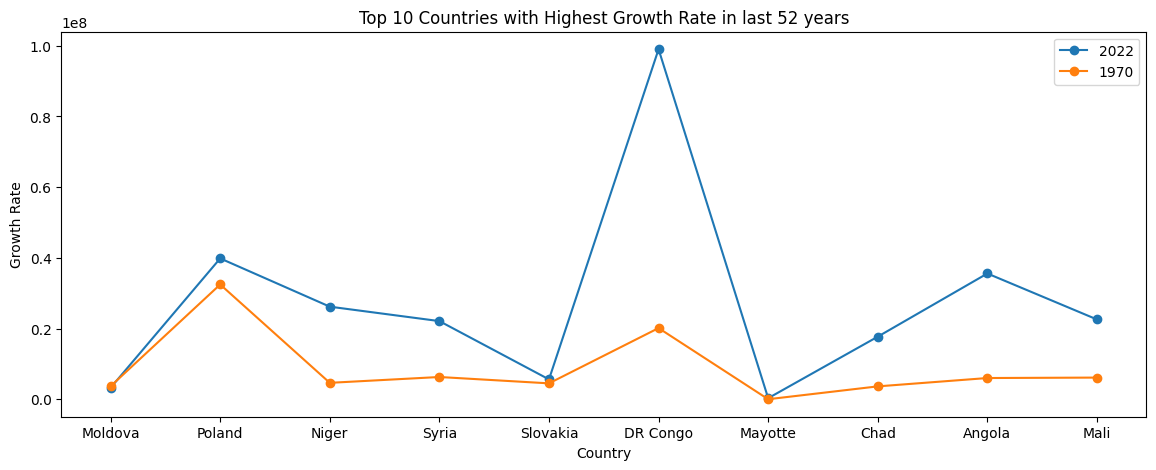

In [139]:
#plot
fig, ax = plt.subplots(figsize=(14, 5))

plt.plot(top10_gr['Country'], top10_gr['2022'], marker = 'o' , label='2022')
plt.plot(top10_gr['Country'], top10_gr['1970'], marker = 'o' , label='1970')

plt.xlabel('Country')
plt.ylabel('Growth Rate')
plt.title('Top 10 Countries with Highest Growth Rate in last 52 years')
plt.legend()
plt.show()

In [140]:
# growth Rate
fig = px.choropleth(df,
                    locations='Country',
                    locationmode='country names',
                    hover_name='Country',
                    color='Growth Rate', # Changed to match the actual column name
                    projection='natural earth',
                    title='Growth Rate')
fig.show()

In [141]:
# Density per sq kme
fig = px.choropleth(df,
                    locations='Country',
                    locationmode='country names',
                    hover_name='Country',
                    color='Density (per km²)', # Changed to the correct column name
                    projection='natural earth',
                    title='Density (per km²)') # Changed title for consistency
fig.show()

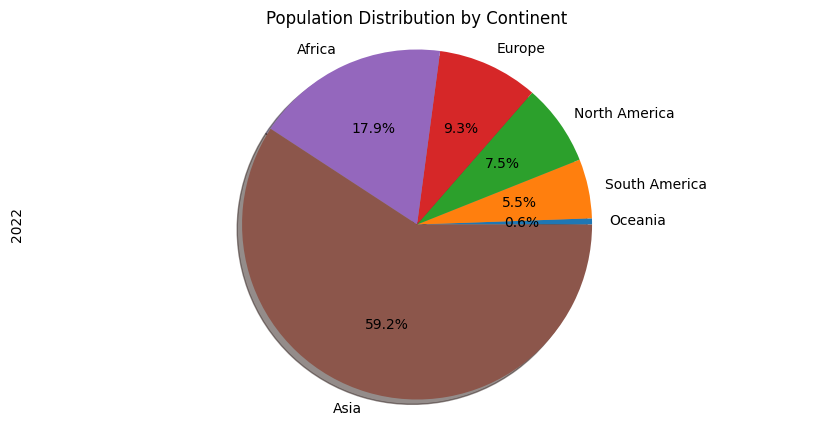

In [142]:
# pie chart distribution
continent_df['2022'].plot(kind='pie', figsize=(10,5), shadow=True, autopct='%1.1f%%')
plt.title('Population Distribution by Continent')
plt.axis('equal')
plt.show()

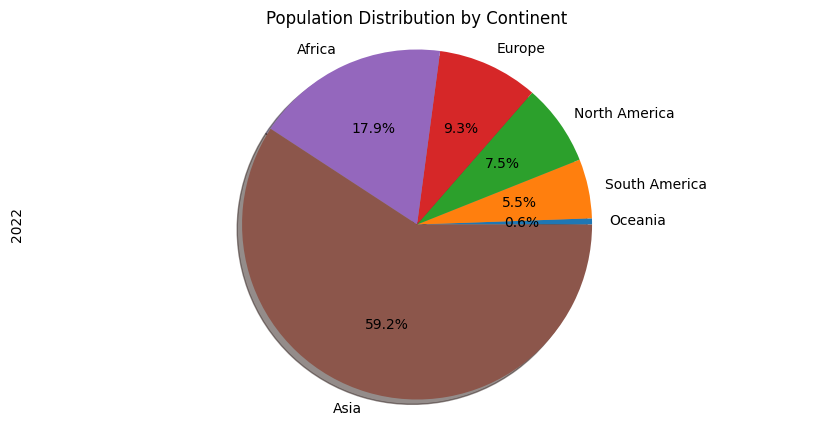

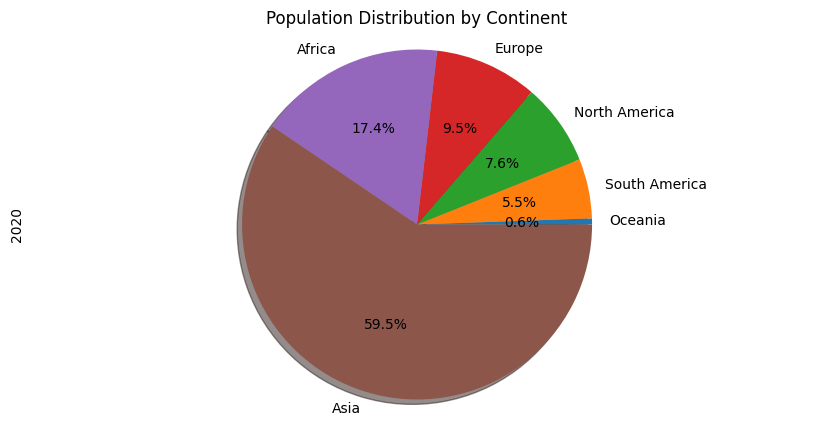

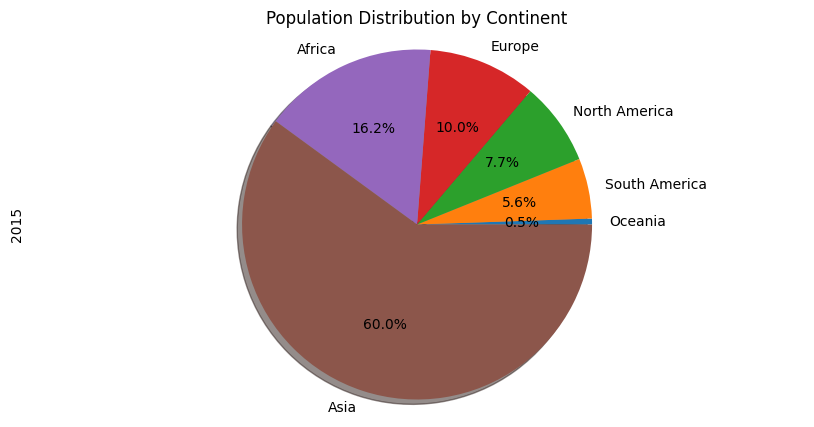

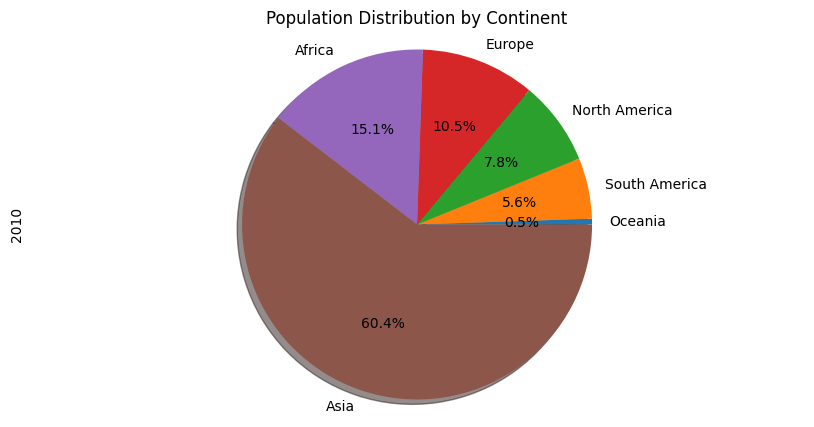

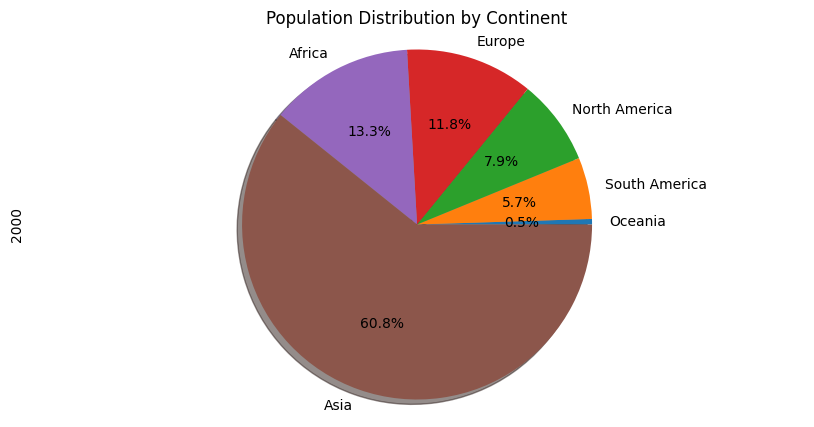

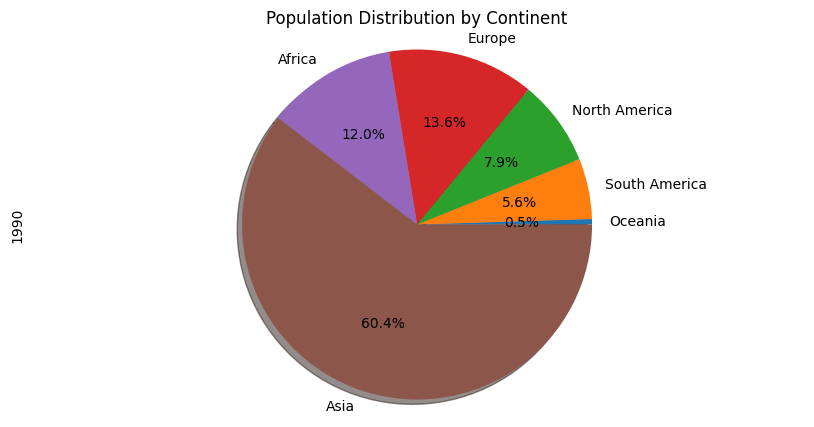

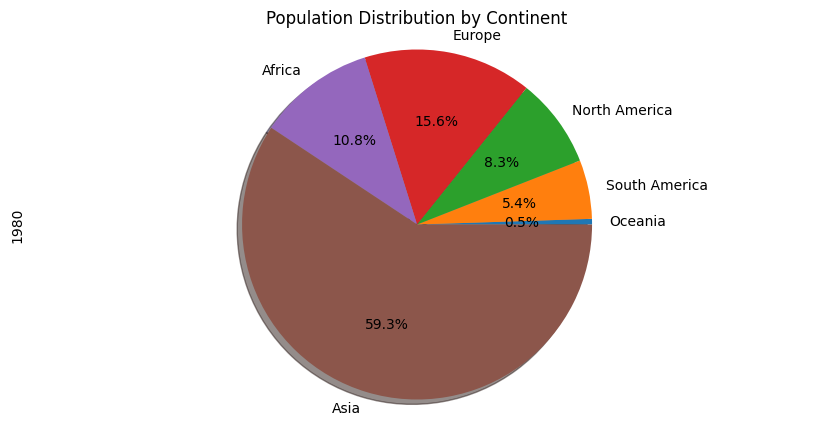

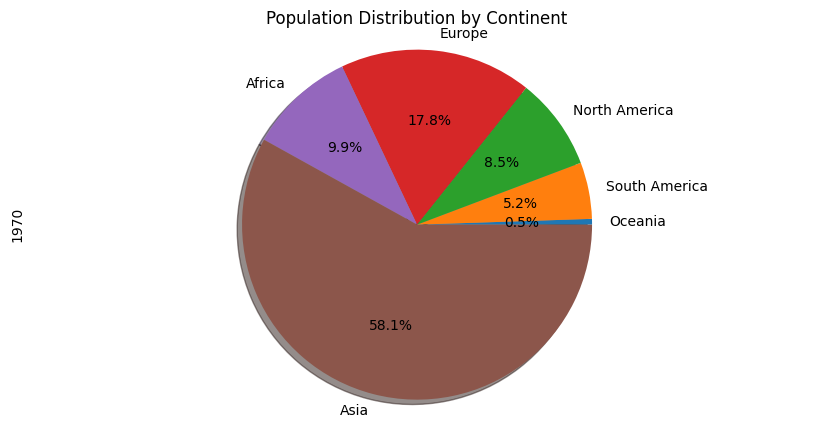

In [143]:
for year in years:
  continent_df[year].plot(kind='pie', figsize=(10,5), shadow=True, autopct='%1.1f%%') # Added 2 spaces for indentation, and changed 'year' to year for correct column access
  plt.title('Population Distribution by Continent')
  plt.axis('equal')
  plt.show()

##### countries per continent

In [144]:
df_country = df['Continent'].value_counts() # Changed 'values_counts()' to 'value_counts()'
df_country

,count
Continent,
Africa,57
Asia,50
Europe,50
North America,40
Oceania,23
South America,14


In [145]:
#plot
fig = px.bar(x = df_country.index,
             y = df_country.values,
             color = df_country.index,
             text = df_country.values,
             title="Number of Countries per Continent")
fig.update_layout(xaxis_title="Countries",
                  yaxis_title="Count")
fig.show()

# Analysis of Population Decade by Decade(1970-2020)

In [146]:
years = ['1970', '1980', '1990', '2000', '2010', '2015', '2020','2022']
continet_pop_bydecade = df.groupby('Continent')[years].sum().sort_values(by='Continent')  # Ensure continet_pop_bydecade is derived from df each time

pop_diff_by_decade = continet_pop_bydecade.copy()  # Create a copy

for i in range(0, 6):
    pop_diff_by_decade[years[i] + '-' + years[i + 1]] = pop_diff_by_decade[years[i]] / pop_diff_by_decade[years[i + 1]] * 100

pop_diff_by_decade = pop_diff_by_decade.groupby('Continent')[['1970-1980', '1980-1990', '1990-2000', '2000-2010', '2010-2015', '2015-2020']].sum().sort_values(by='Continent').reset_index()

In [147]:
pop_diff_by_decade.describe()

,1970-1980,1980-1990,1990-2000,2000-2010,2010-2015,2015-2020
count,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000
mean,83.739198,84.696895,86.732622,87.914025,93.973299,94.499528
std,6.454366,6.966887,6.898899,6.941975,3.810052,3.859226
min,75.891327,75.458106,77.923404,77.608439,87.854960,88.272751
25%,80.197428,81.548551,85.154546,85.241213,92.537521,92.875412
50%,83.190928,83.893081,85.805823,88.728061,94.901134,95.672195
75%,85.483627,86.994695,86.490145,89.408178,95.148897,95.923767
max,94.714551,96.141492,99.204975,98.705773,99.201431,99.429253


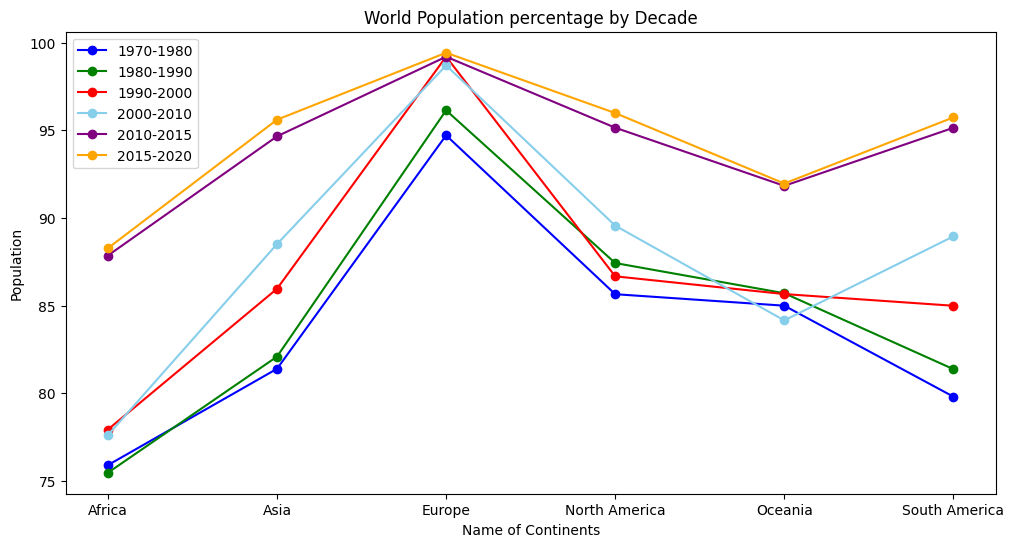

In [148]:
# plot the world population difference
fig,ax = plt.subplots(figsize=(12,6))
plt.plot(pop_diff_by_decade['Continent'], pop_diff_by_decade['1970-1980'], label='1970-1980', marker='o', color='blue')

plt.plot(pop_diff_by_decade['Continent'], pop_diff_by_decade['1980-1990'], label='1980-1990', marker='o', color='green')

plt.plot(pop_diff_by_decade['Continent'], pop_diff_by_decade['1990-2000'], label='1990-2000', marker='o', color='red')

plt.plot(pop_diff_by_decade['Continent'], pop_diff_by_decade['2000-2010'], label='2000-2010', marker='o', color='skyblue')

plt.plot(pop_diff_by_decade['Continent'], pop_diff_by_decade['2010-2015'], label='2010-2015', marker='o', color='purple')

plt.plot(pop_diff_by_decade['Continent'], pop_diff_by_decade['2015-2020'], label='2015-2020', marker='o', color='orange')

plt.xlabel('Name of Continents')
plt.ylabel('Population')
plt.title('World Population percentage by Decade')
plt.legend()
plt.show()

### Top 10 Countries with highhest population

In [149]:
df_copy = df.copy()
df_copy.head()

,Rank,CCA3,Country,Capital,Continent,2022,2020,2015,2010,2000,1990,1980,1970,Area (km²),Density (per km²),Growth Rate,World Population Percentage
0,36,AFG,Afghanistan,Kabul,Asia,41128771,38972230,33753499,28189672,19542982,10694796,12486631,10752971,652230,63.0587,1.0257,0.52
1,138,ALB,Albania,Tirana,Europe,2842321,2866849,2882481,2913399,3182021,3295066,2941651,2324731,28748,98.8702,0.9957,0.04
2,34,DZA,Algeria,Algiers,Africa,44903225,43451666,39543154,35856344,30774621,25518074,18739378,13795915,2381741,18.8531,1.0164,0.56
3,213,ASM,American Samoa,Pago Pago,Oceania,44273,46189,51368,54849,58230,47818,32886,27075,199,222.4774,0.9831,0.00
4,203,AND,Andorra,Andorra la Vella,Europe,79824,77700,71746,71519,66097,53569,35611,19860,468,170.5641,1.0100,0.00


In [150]:
df_copy.set_index('Country', inplace=True)
df_copy.head()

,Rank,CCA3,Capital,Continent,2022,2020,2015,2010,2000,1990,1980,1970,Area (km²),Density (per km²),Growth Rate,World Population Percentage
Country,,,,,,,,,,,,,,,,
Afghanistan,36,AFG,Kabul,Asia,41128771,38972230,33753499,28189672,19542982,10694796,12486631,10752971,652230,63.0587,1.0257,0.52
Albania,138,ALB,Tirana,Europe,2842321,2866849,2882481,2913399,3182021,3295066,2941651,2324731,28748,98.8702,0.9957,0.04
Algeria,34,DZA,Algiers,Africa,44903225,43451666,39543154,35856344,30774621,25518074,18739378,13795915,2381741,18.8531,1.0164,0.56
American Samoa,213,ASM,Pago Pago,Oceania,44273,46189,51368,54849,58230,47818,32886,27075,199,222.4774,0.9831,0.00
Andorra,203,AND,Andorra la Vella,Europe,79824,77700,71746,71519,66097,53569,35611,19860,468,170.5641,1.0100,0.00


In [151]:
df_copy.sort_values(by='2022', ascending=False, inplace=True)
df_copy.head()

,Rank,CCA3,Capital,Continent,2022,2020,2015,2010,2000,1990,1980,1970,Area (km²),Density (per km²),Growth Rate,World Population Percentage
Country,,,,,,,,,,,,,,,,
China,1,CHN,Beijing,Asia,1425887337,1424929781,1393715448,1348191368,1264099069,1153704252,982372466,822534450,9706961,146.8933,1.0000,17.88
India,2,IND,New Delhi,Asia,1417173173,1396387127,1322866505,1240613620,1059633675,870452165,696828385,557501301,3287590,431.0675,1.0068,17.77
United States,3,USA,"Washington, D.C.",North America,338289857,335942003,324607776,311182845,282398554,248083732,223140018,200328340,9372610,36.0935,1.0038,4.24
Indonesia,4,IDN,Jakarta,Asia,275501339,271857970,259091970,244016173,214072421,182159874,148177096,115228394,1904569,144.6529,1.0064,3.45
Pakistan,5,PAK,Islamabad,Asia,235824862,227196741,210969298,194454498,154369924,115414069,80624057,59290872,881912,267.4018,1.0191,2.96


In [152]:
df_top10 = df_copy['2022'].head(10)
df_top10

,2022
Country,
China,1425887337
India,1417173173
United States,338289857
Indonesia,275501339
Pakistan,235824862
Nigeria,218541212
Brazil,215313498
Bangladesh,171186372
Russia,144713314


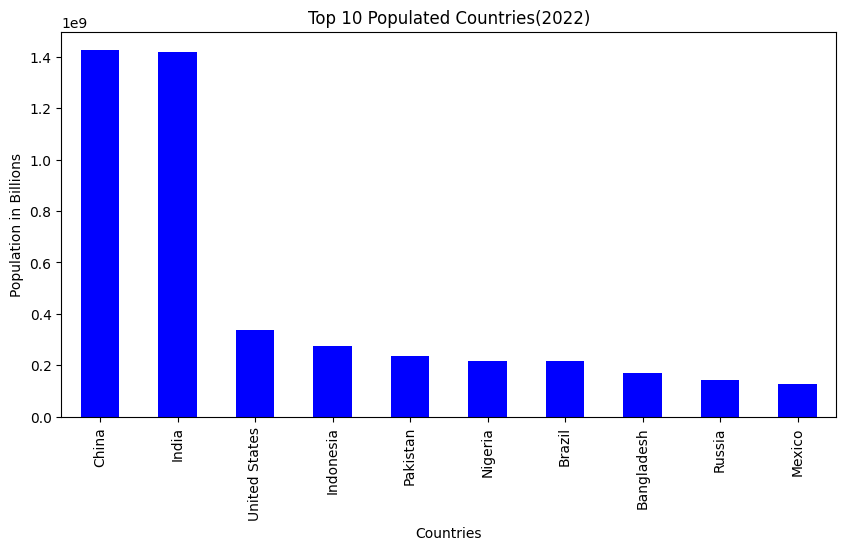

In [153]:
#plot
df_top10.plot(kind='bar', figsize=(10,5), color='blue')
plt.xlabel('Countries')
plt.ylabel('Population in Billions')
plt.title('Top 10 Populated Countries(2022)')
plt.show()

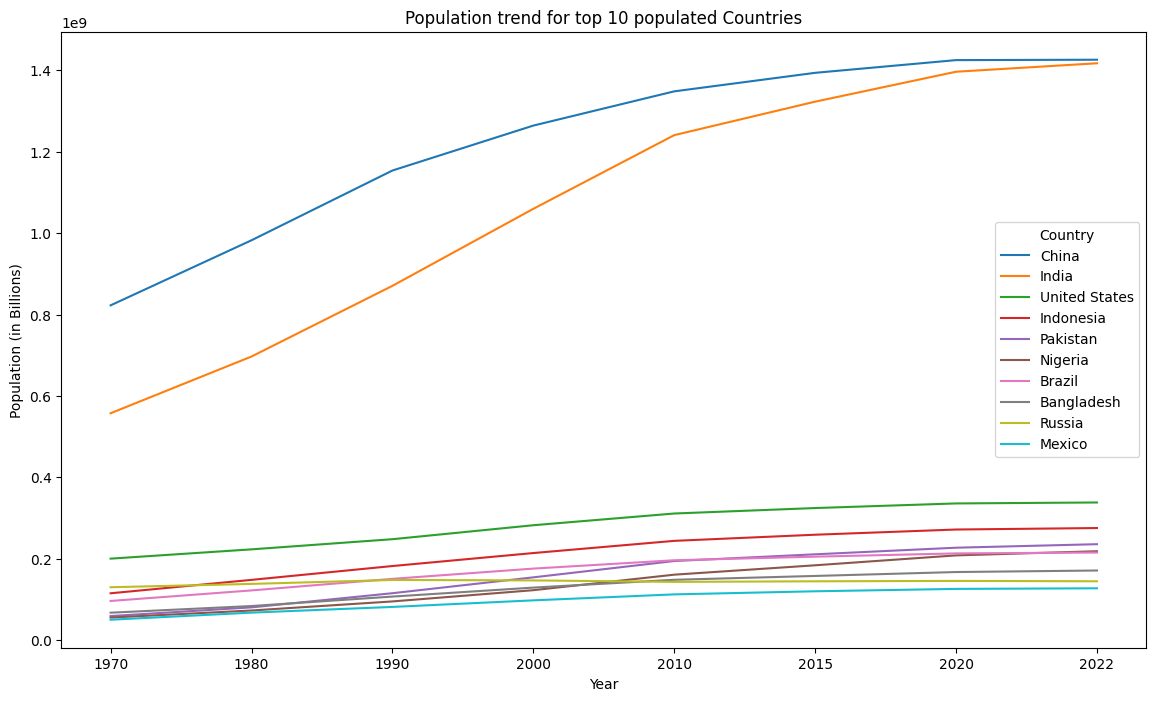

In [154]:
df_top10_trends = df_copy[years].head(10).transpose()
df_top10_index = df_top10_trends.index.map(int)

df_top10_trends.plot(kind='line',figsize=(14,8))

plt.title('Population trend for top 10 populated Countries')

plt.xlabel('Year')
plt.ylabel('Population (in Billions)')
plt.show()



#### 10 least Populated Countries

In [155]:
df_btm10 = df_copy.tail(10)
df_btm10

,Rank,CCA3,Capital,Continent,2022,2020,2015,2010,2000,1990,1980,1970,Area (km²),Density (per km²),Growth Rate,World Population Percentage
Country,,,,,,,,,,,,,,,,
Nauru,225,NRU,Yaren,Oceania,12668,12315,11185,10241,10377,9598,7635,6663,21,603.2381,1.0125,0.0
Wallis and Futuna,226,WLF,Mata-Utu,Oceania,11572,11655,12182,13142,14723,13454,11315,9377,142,81.4930,0.9953,0.0
Tuvalu,227,TUV,Funafuti,Oceania,11312,11069,10877,10550,9638,9182,7731,5814,26,435.0769,1.0096,0.0
Saint Barthelemy,228,BLM,Gustavia,North America,10967,10681,9643,8988,7082,5168,2983,2417,21,522.2381,1.0098,0.0
Saint Pierre and Miquelon,229,SPM,Saint-Pierre,North America,5862,5906,5978,6052,6274,6324,6106,5537,242,24.2231,0.9964,0.0
Montserrat,230,MSR,Brades,North America,4390,4500,5059,4938,5138,10805,11452,11402,102,43.0392,0.9939,0.0
Falkland Islands,231,FLK,Stanley,South America,3780,3747,3408,3187,3080,2332,2240,2274,12173,0.3105,1.0043,0.0
Niue,232,NIU,Alofi,Oceania,1934,1942,1847,1812,2074,2533,3637,5185,260,7.4385,0.9985,0.0
Tokelau,233,TKL,Nukunonu,Oceania,1871,1827,1454,1367,1666,1669,1647,1714,12,155.9167,1.0119,0.0


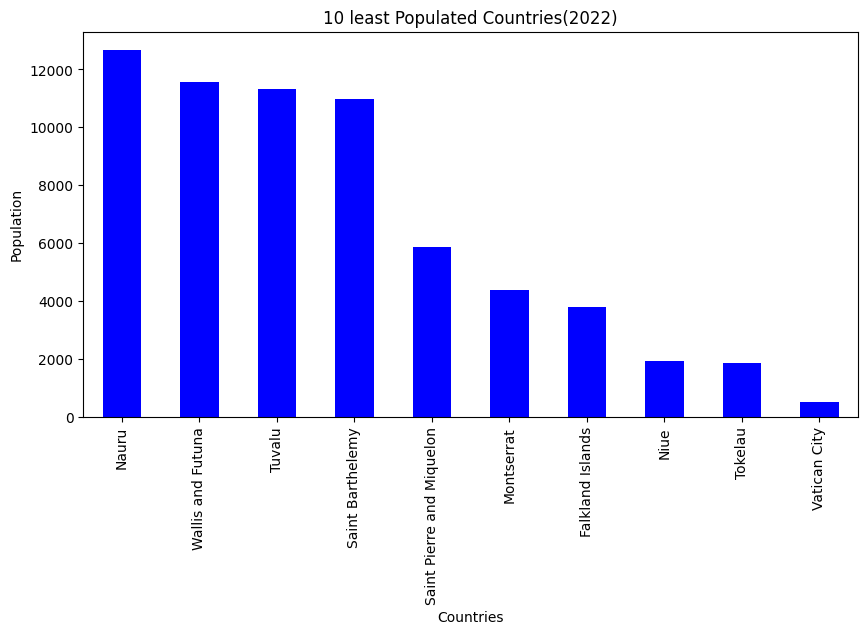

In [156]:
df_btm10['2022'].plot(kind='bar', figsize=(10,5), color='blue')
plt.xlabel('Countries')
plt.ylabel('Population')
plt.title('10 least Populated Countries(2022)')
plt.show()

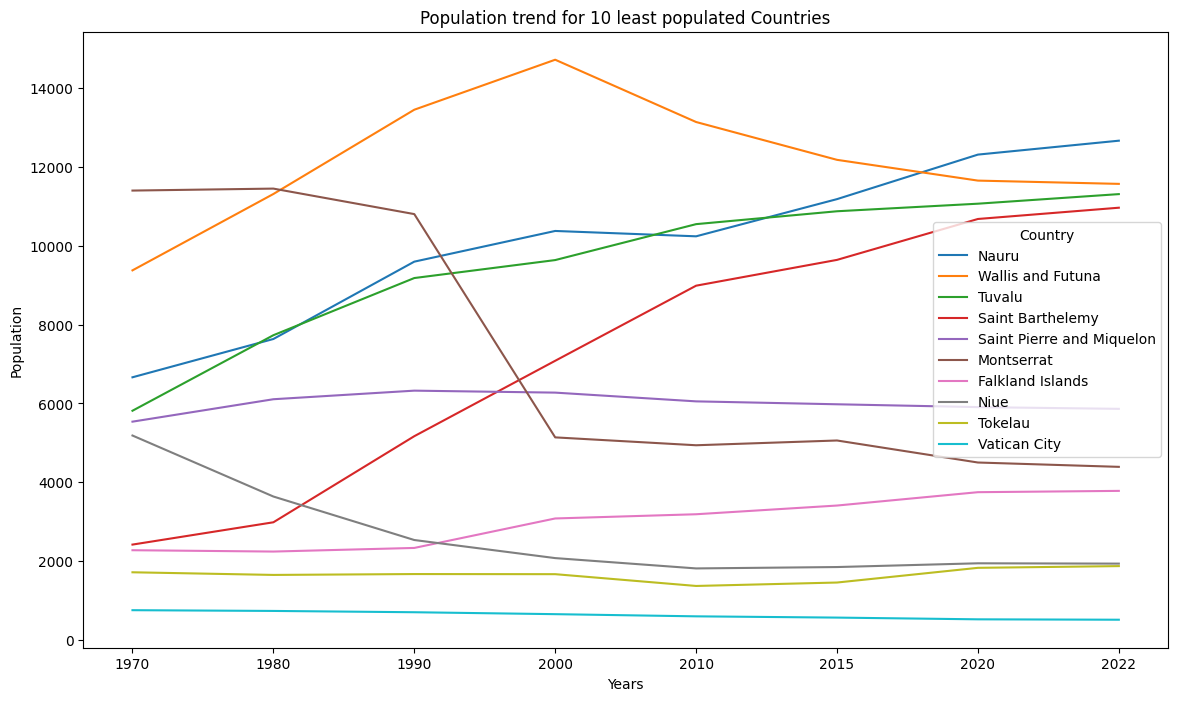

In [157]:
df_btm10_trends = df_btm10[years].head(10).transpose()
# df_btm10_trends
df_btm10_index = df_btm10_trends.index.map(int)

df_btm10_trends.plot(kind='line',figsize=(14,8))

plt.title('Population trend for 10 least populated Countries')

plt.xlabel('Years')
plt.ylabel('Population')
plt.show()


### 5 Populated Countries per continent

<Axes: title={'center': 'Top 5 Populated Asian Countries'}, xlabel='Country', ylabel='Population(in Billion)'>

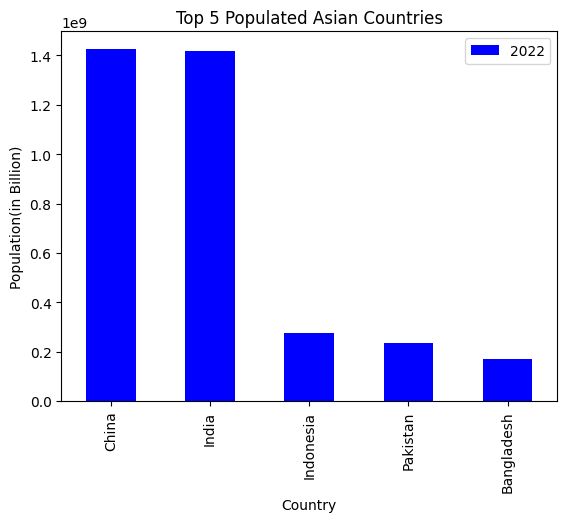

In [158]:
asian_Countries = df[df['Continent'].str.lower() == 'asia'].sort_values(by=['2022'], ascending=False, ignore_index=True)[['Country', '2022']]
asian_Countries.head().plot.bar(x='Country', ylabel="Population(in Billion)", title="Top 5 Populated Asian Countries", color='blue')

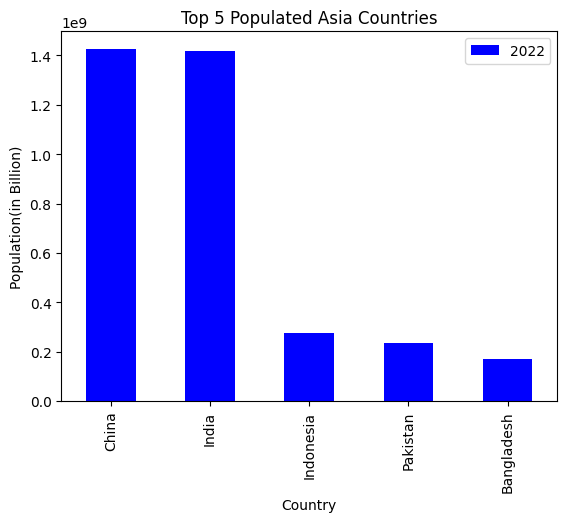

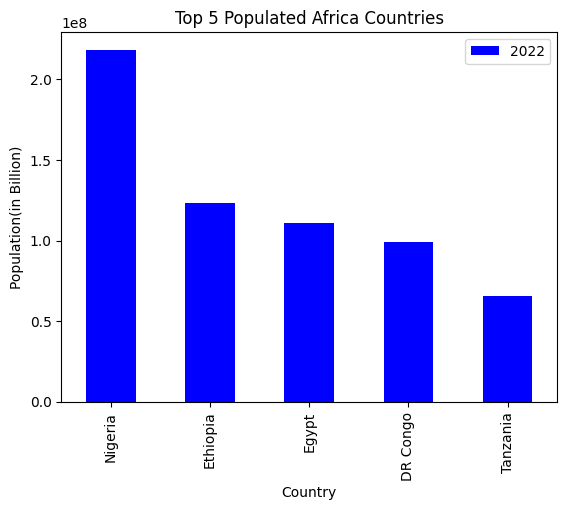

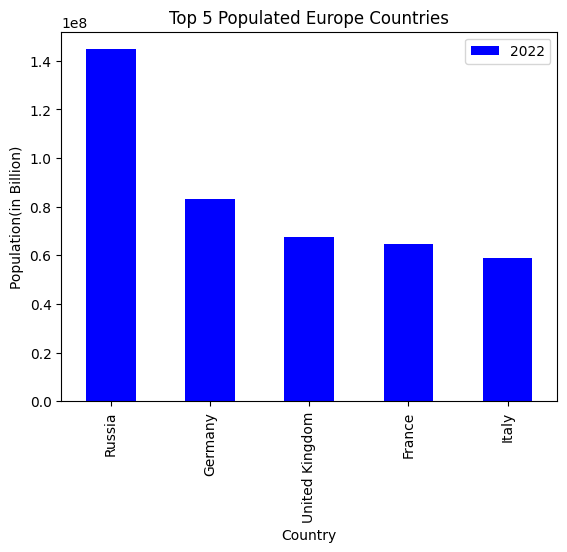

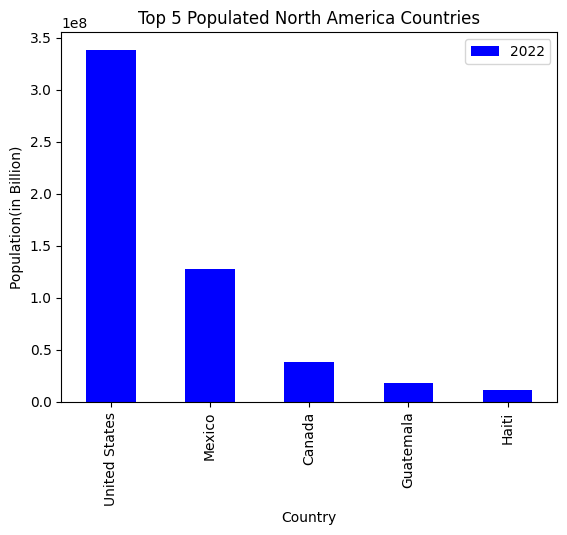

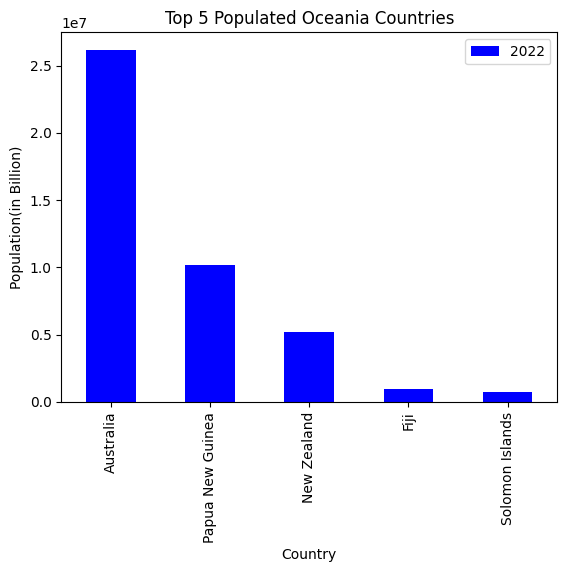

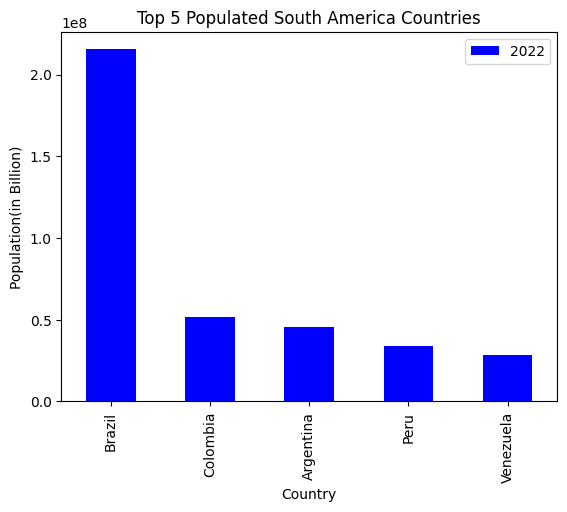

In [159]:
continents = ["Asia", "Africa", "Europe", "North America", "Oceania", "South America"]

for continent in continents:
   df[df['Continent'] == continent].sort_values(by=['2022'], ascending=False, ignore_index=True)[['Country', '2022']].head().plot.bar(x='Country', ylabel="Population(in Billion)", title=f"Top 5 Populated "+continent+" Countries", color='blue')

#### Leat Populated Countries per continent

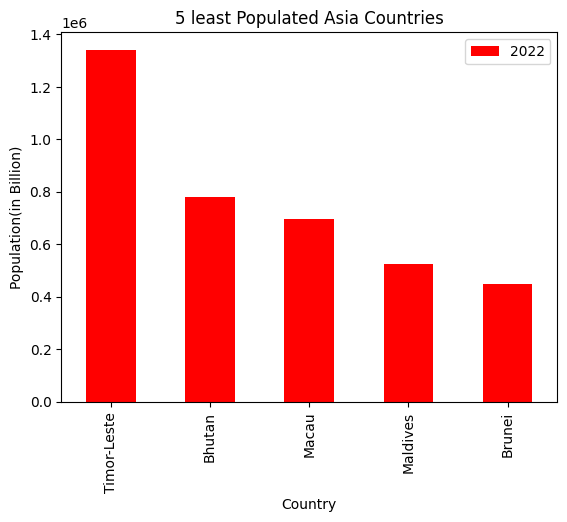

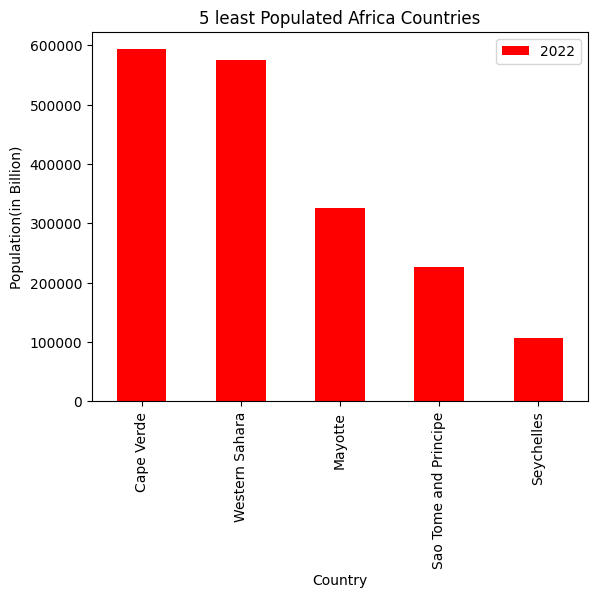

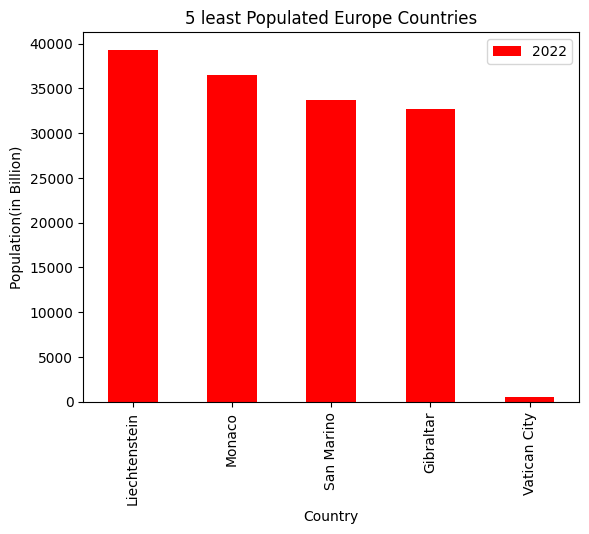

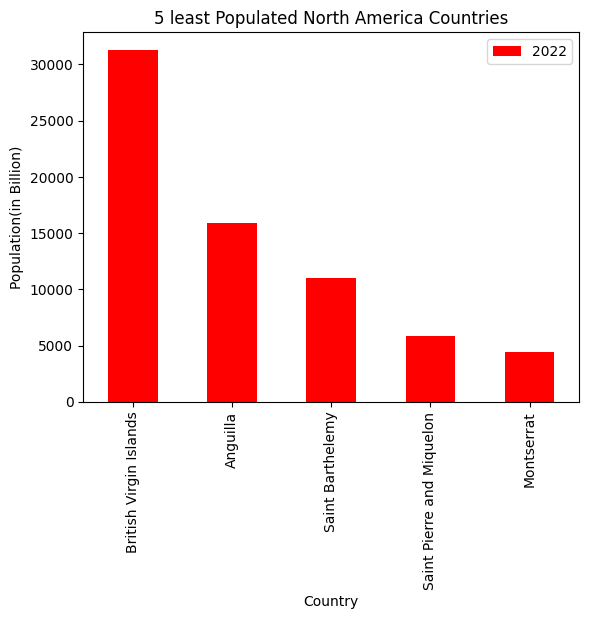

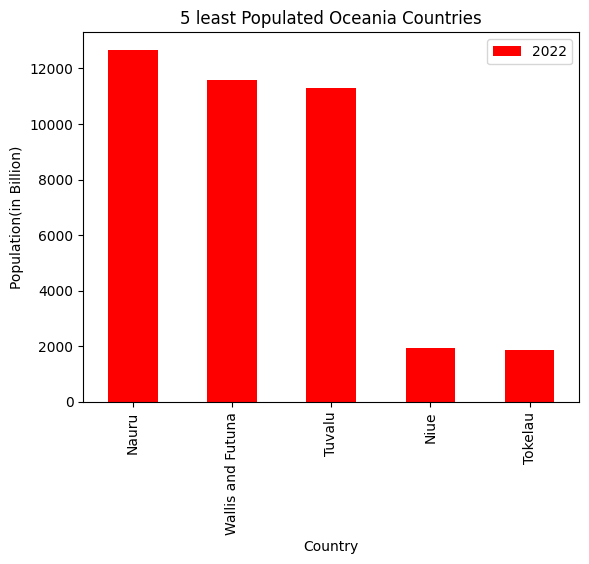

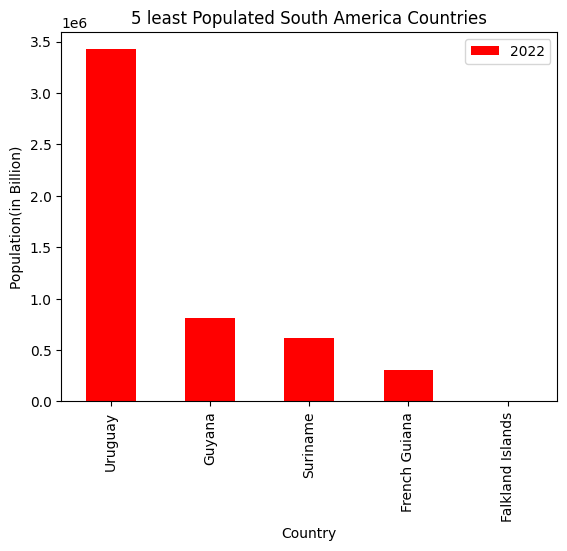

In [160]:
continents = ["Asia", "Africa", "Europe", "North America", "Oceania", "South America"]

for continent in continents:
  df[df['Continent'] == continent].sort_values(by=['2022'], ascending=False, ignore_index=True)[['Country', '2022']].tail().plot.bar(x="Country", ylabel="Population(in Billion)", title=f"5 least Populated "+continent+" Countries", color='red')

### Projection of Population till 2030

In [161]:
print("Population till 2022:", df['2022'].sum())

Population till 2022: 7973413042


In [162]:
df_total_pop = pd.DataFrame(df[years].sum(axis=0))
df_total_pop

,0
1970,3694136661
1980,4442400371
1990,5314191665
2000,6147055703
2010,6983784998
2015,7424809761
2020,7839250603
2022,7973413042


In [163]:
df_total_pop.index = map(int, df_total_pop.index)

In [164]:
df_total_pop.reset_index(inplace=True)

In [165]:
df_total_pop.columns=['years','total']
df_total_pop

,years,total
0,1970,3694136661
1,1980,4442400371
2,1990,5314191665
3,2000,6147055703
4,2010,6983784998
5,2015,7424809761
6,2020,7839250603
7,2022,7973413042


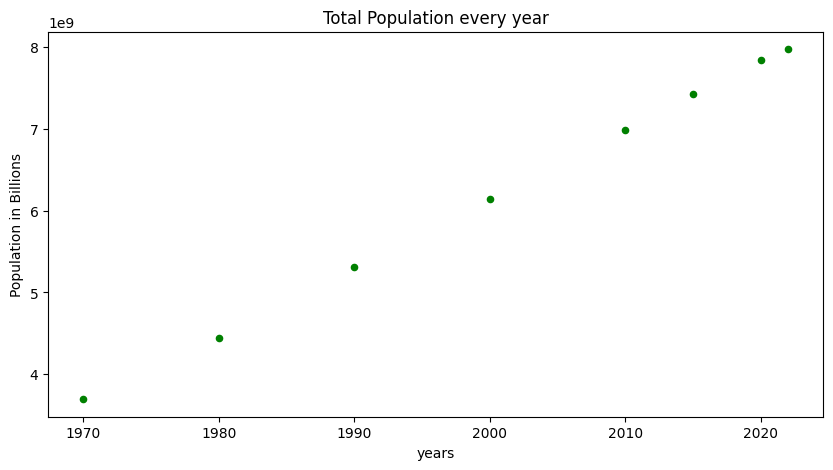

In [166]:
df_total_pop.plot(kind = 'scatter', x='years',y='total', color='green', figsize=(10,5),title='Total Population every year',ylabel='Population in Billions')
plt.show()

In [167]:
x = df_total_pop['years']
y = df_total_pop['total']
fit_data = np.polyfit(x,y,deg=1)
fit_data

array([ 8.33710451e+07, -1.60587660e+11])

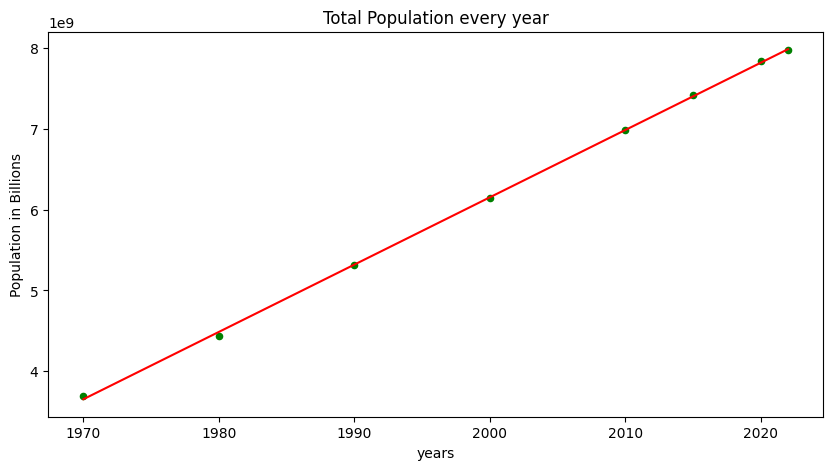

In [168]:
df_total_pop.plot(kind = 'scatter', x='years',y='total', color='green', figsize=(10,5),title='Total Population every year',ylabel='Population in Billions')

predicted_y = fit_data[0] * x + fit_data[1] #y = mx + c

plt.plot(x, predicted_y, color='red') # Plot the line of best fit

In [169]:
print("Projected world Population by 2030:",fit_data[0]*2030 + fit_data[1])

Projected world Population by 2030: 8655562039.158783


## Projection for Africa

In [170]:
african_countries=df[df['Continent'] == 'Africa'].sort_values(by=['2022'], ascending=False, ignore_index=True)
african_countries.head()


,Rank,CCA3,Country,Capital,Continent,2022,2020,2015,2010,2000,1990,1980,1970,Area (km²),Density (per km²),Growth Rate,World Population Percentage
0,6,NGA,Nigeria,Abuja,Africa,218541212,208327405,183995785,160952853,122851984,95214257,72951439,55569264,923768,236.5759,1.0241,2.74
1,12,ETH,Ethiopia,Addis Ababa,Africa,123379924,117190911,102471895,89237791,67031867,47878073,34945469,28308246,1104300,111.7268,1.0257,1.55
2,14,EGY,Egypt,Cairo,Africa,110990103,107465134,97723799,87252413,71371371,57214630,43748556,34781986,1002450,110.7188,1.0158,1.39
3,15,COD,DR Congo,Kinshasa,Africa,99010212,92853164,78656904,66391257,48616317,35987541,26708686,20151733,2344858,42.2244,1.0325,1.24
4,22,TZA,Tanzania,Dodoma,Africa,65497748,61704518,52542823,45110527,34463704,26206012,19297659,13618192,945087,69.3034,1.0300,0.82


In [171]:
df_african_country=pd.DataFrame(african_countries[years].sum(axis=0))

df_african_country.index = map(int, df_african_country.index)

df_african_country.reset_index(inplace=True)

df_african_country.columns=['years','total']
df_african_country


,years,total
0,1970,365444348
1,1980,481536377
2,1990,638150629
3,2000,818946032
4,2010,1055228072
5,2015,1201102442
6,2020,1360671810
7,2022,1426730932


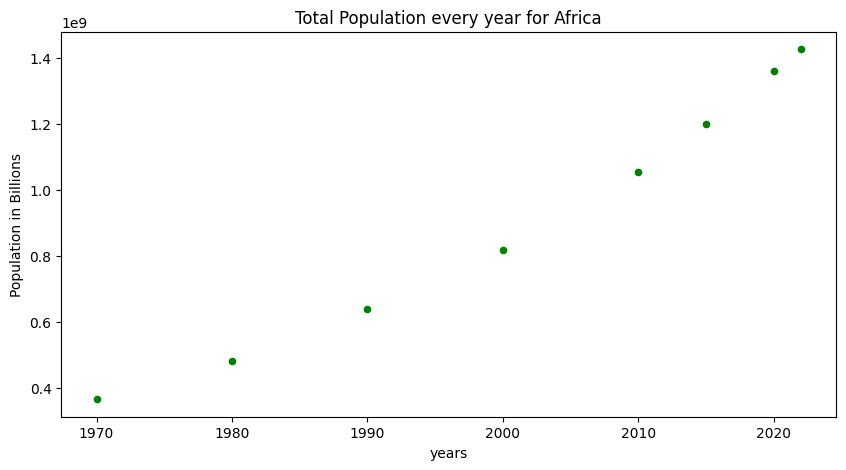

In [172]:
df_african_country.plot(kind = 'scatter', x='years',y='total', color='green', figsize=(10,5),title='Total Population every year for Africa',ylabel='Population in Billions')
plt.show()

In [173]:
x = df_african_country['years']
y = df_african_country['total']
fit_data = np.polyfit(x,y,deg=1)
fit_data

array([ 2.06561727e+07, -4.04119432e+10])

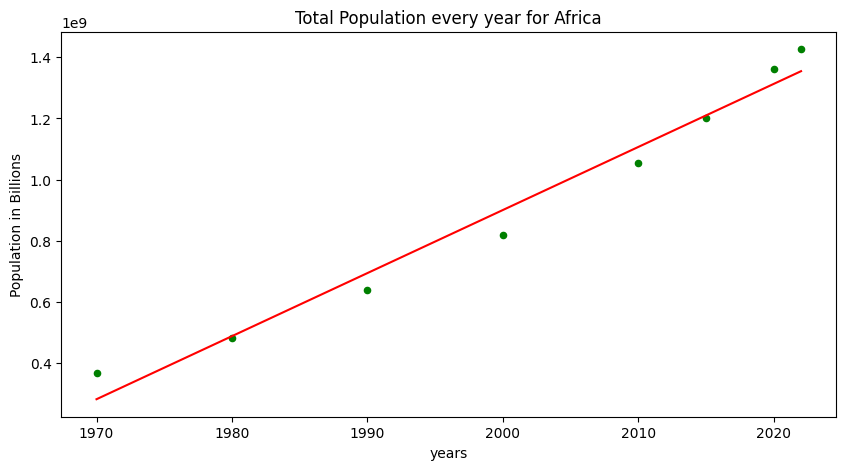

In [174]:
df_african_country.plot(kind = 'scatter', x='years',y='total', color='green', figsize=(10,5),title='Total Population every year for Africa',ylabel='Population in Billions')

predicted_y = fit_data[0] * x + fit_data[1] #y = mx + c

plt.plot(x, predicted_y, color='red') # Plot the line of best fit

In [175]:
print("Projected Africa Population by 2050:",fit_data[0]*2050 + fit_data[1])

Projected Africa Population by 2050: 1933210813.3021088


##### comparison of Population for india and China

In [176]:
df_China_India = df_copy.loc[['China','India'],years]


In [177]:
df_China_India=df_China_India.transpose()
df_China_India

Country,China,India
1970,822534450,557501301
1980,982372466,696828385
1990,1153704252,870452165
2000,1264099069,1059633675
2010,1348191368,1240613620
2015,1393715448,1322866505
2020,1424929781,1396387127
2022,1425887337,1417173173


In [178]:
df_China_India.describe()

Country,China,India
count,8.000000e+00,8.000000e+00
mean,1.226929e+09,1.070182e+09
std,2.240527e+08,3.299235e+08
min,8.225344e+08,5.575013e+08
25%,1.110871e+09,8.270462e+08
50%,1.306145e+09,1.150124e+09
75%,1.401519e+09,1.341247e+09
max,1.425887e+09,1.417173e+09


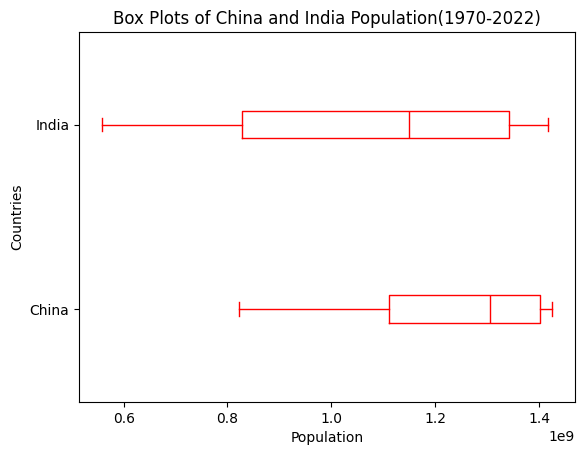

In [179]:
df_China_India.plot(kind='box',color='red', vert=False, title='Box Plots of China and India Population(1970-2022)', xlabel='Population', ylabel='Countries')
plt.show()

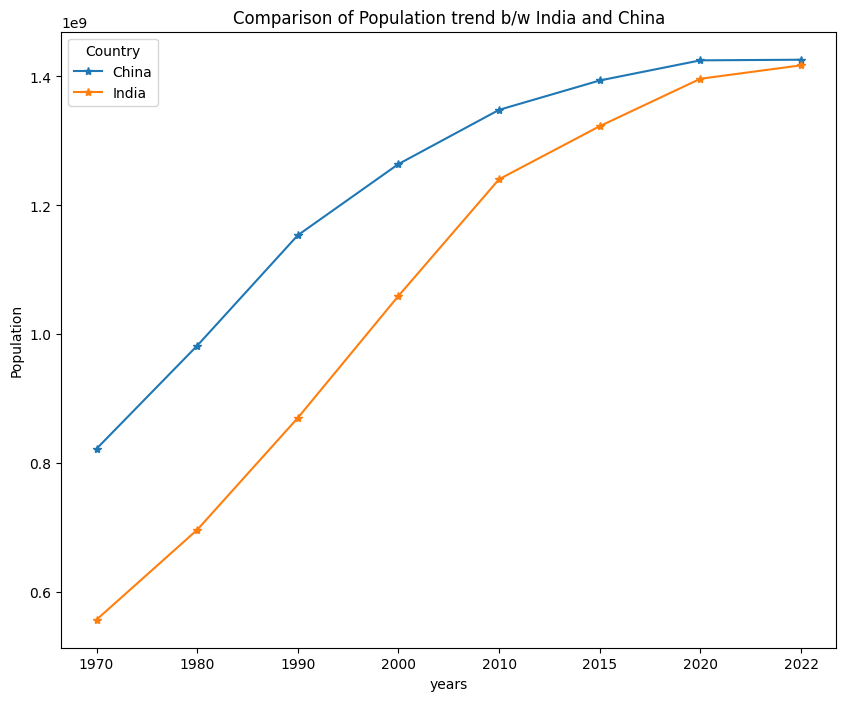

In [180]:
df_China_India.plot(kind='line',figsize=(10,8),
                    title='Comparison of Population trend b/w India and China',
                    xlabel='years',
                    ylabel='Population',
                    marker="*")

plt.show()